### Towards a better understanding of Word Embeddings
To get a better understanding of what's actually happening with word embeddings, let's start with something small.

In [106]:
plants = [
    {'name': 'basil', 'size': 5, 'difficulty': 10},
    {'name': 'aloe vera', 'size': 10, 'difficulty': 15},
    {'name': 'lavender', 'size': 20, 'difficulty': 30},
    {'name': 'monstera', 'size': 50, 'difficulty': 35},
    {'name': 'sunflower', 'size': 40, 'difficulty': 25},
    {'name': 'snake plant', 'size': 25, 'difficulty': 10},
    {'name': 'orchid', 'size': 15, 'difficulty': 70},
    {'name': 'oak tree', 'size': 90, 'difficulty': 50},
    {'name': 'maple tree', 'size': 85, 'difficulty': 55},
    {'name': 'cactus (saguaro)', 'size': 80, 'difficulty': 40},
    {'name': 'venus flytrap', 'size': 4, 'difficulty': 85},
    {'name': 'hydrangea', 'size': 30, 'difficulty': 35},
    {'name': 'banana plant', 'size': 60, 'difficulty': 45},
    {'name': 'bonsai tree', 'size': 10, 'difficulty': 95}
]

We can observe it in a clearer way using the DataFrame data type from the library `pandas`. Let's install it first.

In [67]:
!pip install pandas

In [95]:
import pandas as pd
pd.DataFrame(plants, columns=['name', 'size', 'difficulty'])

,name,size,difficulty
0,basil,5,10
1,aloe vera,10,15
2,lavender,20,30
3,succulent (generic),3,5
4,sunflower,40,25
5,snake plant,25,10
6,orchid,15,70
7,oak tree,90,50
8,maple tree,85,55
9,cactus (saguaro),80,40


Here we see a list of plants, each gets a score between 0-100 for their size and difficulty to take care of. These scores are not based on any scientific studies and are very subjective based on my personal experience. To get a good visual representation of this small dataset, we can use the library `matplotlib`.

In [80]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 14.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 12.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 13.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


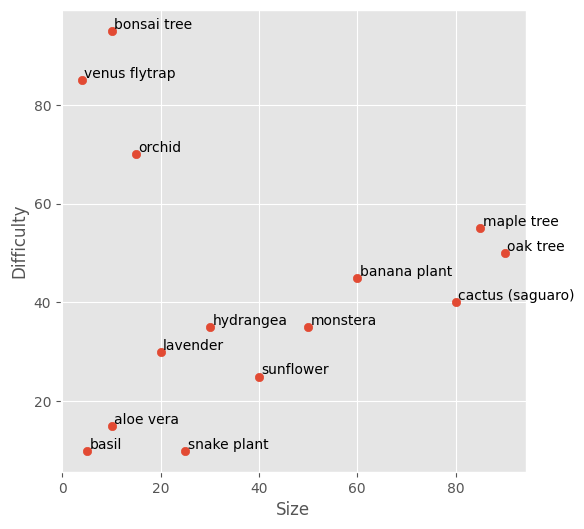

In [131]:
import matplotlib.pyplot as plt
plt.style.use('ggplot') # specify the plotting style

# Turning the list of plants into a dictionary that maps between the name of the plant and their size/difficulty values as a tuple.
plants2d = {plant['name']: (plant['size'], plant['difficulty']) for plant in plants}

# plot plants_2d
plt.figure(figsize=(6, 6))
# creating a plot based on x - size, y - difficulty
plt.scatter([item[0] for item in plants2d.values()],
            [item[1] for item in plants2d.values()])
plt.xlabel('Size')
plt.ylabel('Difficulty')
for key, (size, difficulty) in plants2d.items():
    plt.text(size+0.5, difficulty+0.5, key)
plt.show()

In this 2-dimensional vector space for our list of plants, we can observe that basil and aloe vera are more similar than basil and maple tree. This similarity can be represented mathematically by calculating the Euclidean distance between two points.

In [130]:
import math
def distance2d(x, y):
    # The math.dist() method returns the Euclidean distance between two points
    return math.dist(x, y)

print(f"Distance between basil {plants2d["basil"]} and aloe vera {plants2d["aloe vera"]}",  distance2d(plants2d["basil"], plants2d["aloe vera"]))
print(f"Distance between basil {plants2d["basil"]} and maple tree {plants2d["maple tree"]}", distance2d(plants2d["basil"], plants2d["maple tree"]))

Distance between basil (5, 10) and aloe vera (10, 15) 7.0710678118654755
Distance between basil (5, 10) and maple tree (85, 55) 91.7877987534291


If we take lavender as our reference point in this space, we can sort the whole list of plants based on how similar they are to lavender (considering only size & difficulty). You can change the ref plant in the code cell below to any other plant in the list that you want to check.

In [129]:
ref = "lavender"
sorted(plants,
       key=lambda x: distance2d(plants2d[ref], plants2d[x['name']]))

[{'name': 'lavender', 'size': 20, 'difficulty': 30},
 {'name': 'hydrangea', 'size': 30, 'difficulty': 35},
 {'name': 'aloe vera', 'size': 10, 'difficulty': 15},
 {'name': 'sunflower', 'size': 40, 'difficulty': 25},
 {'name': 'snake plant', 'size': 25, 'difficulty': 10},
 {'name': 'basil', 'size': 5, 'difficulty': 10},
 {'name': 'monstera', 'size': 50, 'difficulty': 35},
 {'name': 'orchid', 'size': 15, 'difficulty': 70},
 {'name': 'banana plant', 'size': 60, 'difficulty': 45},
 {'name': 'venus flytrap', 'size': 4, 'difficulty': 85},
 {'name': 'cactus (saguaro)', 'size': 80, 'difficulty': 40},
 {'name': 'bonsai tree', 'size': 10, 'difficulty': 95},
 {'name': 'maple tree', 'size': 85, 'difficulty': 55},
 {'name': 'oak tree', 'size': 90, 'difficulty': 50}]

Here we have a <b>lamda</b> function. It is an anonymous (unnamed) function. This lambda takes one argument, x, and returns one value (the distance). It is the same as writing the following:

In [134]:
def anonymous_function(x):
    return distance2d(plants2d[ref], plants2d[x['name']])

Another example is to sort the plant by size

In [136]:
sorted(plants, key=lambda x: x['size'])

[{'name': 'venus flytrap', 'size': 4, 'difficulty': 85},
 {'name': 'basil', 'size': 5, 'difficulty': 10},
 {'name': 'aloe vera', 'size': 10, 'difficulty': 15},
 {'name': 'bonsai tree', 'size': 10, 'difficulty': 95},
 {'name': 'orchid', 'size': 15, 'difficulty': 70},
 {'name': 'lavender', 'size': 20, 'difficulty': 30},
 {'name': 'snake plant', 'size': 25, 'difficulty': 10},
 {'name': 'hydrangea', 'size': 30, 'difficulty': 35},
 {'name': 'sunflower', 'size': 40, 'difficulty': 25},
 {'name': 'monstera', 'size': 50, 'difficulty': 35},
 {'name': 'banana plant', 'size': 60, 'difficulty': 45},
 {'name': 'cactus (saguaro)', 'size': 80, 'difficulty': 40},
 {'name': 'maple tree', 'size': 85, 'difficulty': 55},
 {'name': 'oak tree', 'size': 90, 'difficulty': 50}]

We can also calculate an ideal average plant that doesn't exist in our list:

In [132]:
avg_size = sum(p['size'] for p in plants) / len(plants)
avg_difficulty = sum(p['difficulty'] for p in plants) / len(plants)

print("Average size:", avg_size)
print("Average difficulty:", avg_difficulty)

Average size: 37.42857142857143
Average difficulty: 42.857142857142854


And sort our list of plants according to how close they are to the ideal average.

In [133]:
sorted(plants,
       key=lambda x: distance2d((avg_size, avg_difficulty), plants2d[x['name']]))

[{'name': 'hydrangea', 'size': 30, 'difficulty': 35},
 {'name': 'monstera', 'size': 50, 'difficulty': 35},
 {'name': 'sunflower', 'size': 40, 'difficulty': 25},
 {'name': 'lavender', 'size': 20, 'difficulty': 30},
 {'name': 'banana plant', 'size': 60, 'difficulty': 45},
 {'name': 'snake plant', 'size': 25, 'difficulty': 10},
 {'name': 'orchid', 'size': 15, 'difficulty': 70},
 {'name': 'aloe vera', 'size': 10, 'difficulty': 15},
 {'name': 'cactus (saguaro)', 'size': 80, 'difficulty': 40},
 {'name': 'basil', 'size': 5, 'difficulty': 10},
 {'name': 'maple tree', 'size': 85, 'difficulty': 55},
 {'name': 'oak tree', 'size': 90, 'difficulty': 50},
 {'name': 'venus flytrap', 'size': 4, 'difficulty': 85},
 {'name': 'bonsai tree', 'size': 10, 'difficulty': 95}]

---
### Word Embeddings
Word Embeddings in the real world are similar to the example above, but with more dimensions representing their meaning captured from the training data. Usually they tend to have very high dimension during the training process, but the final word embeddings are usually reduced to a dimensionality of 300 or lower.

We can play with word embeddings directly in spaCy. spaCy used to use [the gloVe embeddings](https://nlp.stanford.edu/projects/glove/), now it is using its own embeddings, Explosion. Let's first download both `en_core_web_md` and `en_core_web_lg`. As the small model doesn't include word vectors.

In [96]:
!python -m spacy download en_core_web_md; python -m spacy download en_core_web_lg

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_md-3.8.0/en_core_web_md-3.8.0-py3-none-any.whl (33.5 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_lg-3.8.0/en_core_web_lg-3.8.0-py3-none-any.whl (400.7 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')


Then import spacy and load the language models we just downloaded.

In [97]:
import spacy
nlp = spacy.load("en_core_web_md")
nlp_large = spacy.load("en_core_web_lg")

You can check the vector of any word using spacing by checking the `vector` attribute.

In [149]:
nlp.vocab['speak'].vector

array([-6.2774e-01,  3.9978e-01, -4.7624e-01,  1.5001e-01, -3.5657e-01,
       -1.8639e-01, -9.8144e-02, -2.4939e-01, -1.4997e-01,  2.7316e+00,
       -2.1371e-01, -2.8849e-01,  1.4713e-01, -1.6796e-01, -3.7062e-01,
        4.0618e-01,  1.5978e-02,  1.0757e+00, -4.7995e-01, -3.3348e-01,
        1.0255e-01, -1.2375e-01,  2.6667e-01, -5.6767e-01,  1.2458e-01,
        3.2570e-01, -8.2681e-02,  1.1403e-01,  2.9947e-01, -3.5775e-01,
       -6.5165e-01,  3.6489e-01, -5.1581e-01, -3.6734e-01,  2.5070e-01,
        4.5203e-02, -1.2011e-01,  8.2486e-02,  6.3345e-02, -4.1344e-01,
       -3.3446e-01, -6.0630e-01, -1.0259e-01, -3.4859e-01, -1.6446e-01,
       -7.3494e-03, -2.3318e-01,  1.0198e-01, -3.9395e-01, -8.0910e-02,
       -1.9421e-01,  9.5100e-03, -2.7774e-01, -3.7724e-01,  6.4068e-02,
        1.6218e-01, -5.8869e-01, -1.8021e-01, -2.1038e-01,  2.5797e-02,
       -2.2447e-02,  3.8924e-01,  1.1580e-01, -1.8635e-01,  6.1270e-02,
       -1.6675e-01, -1.9614e-01, -7.3784e-02,  2.2808e-01, -8.60



We can check the dimension of any word vector using the `shape` attribute. spaCy's English model uses 300-dimensional word vectors. Most of the word embeddings you can find online have a dimension of 300. This size was found to be a good balance between capturing enough semantic information and keeping model complexity manageable

In [72]:
nlp.vocab['speak'].vector.shape

(300,)

We can use `.similarity` method to check if two words are neighbors inside the vector space. Notice that we can only call it on [Doc](https://spacy.io/api/doc)/[Span](https://spacy.io/api/span)/[Token](https://spacy.io/api/token)/[Lexeme](https://spacy.io/api/lexeme) objects. The default estimate is cosine similarity between two vectors. When we just want to compare words without context, `Lexeme` works faster because a Lexeme has no string context. It has no part-of-speech tag, dependency parse, or lemma.

In the example below, cat and dog are closer in meaning than cat and red, so their word vectors should be nearer to each other.

In [73]:
# different objects in spaCy
doc = nlp("I love cat")
print(type(doc))
token = doc[0]
print(type(token), token.text)
span = doc[1:3]
print(type(span), span.text)
lexeme = nlp.vocab["cat"]
print(type(lexeme))

lexeme2 = nlp.vocab["dog"]
lexeme3 = nlp.vocab["red"]
print(token.similarity(lexeme2))
print(token.similarity(lexeme3))

<class 'spacy.tokens.doc.Doc'>
<class 'spacy.tokens.token.Token'> I
<class 'spacy.tokens.span.Span'> love cat
<class 'spacy.lexeme.Lexeme'>
0.20646506547927856
0.15639866888523102


Simply comparing the distance between two specific words isn’t very interesting. It’s far more useful if we can discover similar words using this method.Because in the vector space of word embeddings similar words are located near one another, to find similar words is to find nearest neighbors of a given word.

However, we don’t want to compute distances against every word embedding in the model, because there are far too many. The model we are using contains more than 20k vectors but over 68k tokens in total. Many tokens don’t have vectors, and some share the same vector.

In [169]:
nlp.meta['vectors'] # getting meta deta about the vectors contained in the model we are using

{'width': 300,
 'vectors': 20000,
 'keys': 684830,
 'name': 'en_vectors',
 'mode': 'default'}

To make our result more feasible and faster to compute, we will try to filter our word embeddings with the most common 10k English words (no swears) based on google n-gram from [this source](https://github.com/first20hours/google-10000-english?tab=readme-ov-file). Now let's download the file first:

In [147]:
!curl -L -O https://raw.githubusercontent.com/first20hours/google-10000-english/refs/heads/master/google-10000-english-usa-no-swears.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 75071  100 75071    0     0   397k      0 --:--:-- --:--:-- --:--:--  398k


And compile a list of common english words based on it.

In [56]:
with open("google-10000-english-usa-no-swears.txt") as f:
    text = f.read()
common_words = text.split("\n")
print(len(common_words))

9884


In the following code cell, we are trying to find the 10 nearest neighbor words of 'cat'. Keep in mind that we’re using a relatively small model for this task, so some of the results you see may not fully make sense.

In [78]:
def nearest_neighbors(target, vocab, k=5):
    """
    Find the nearest neighbors of a target word within a vocab
    vocab needs to be a list of strings
    """
    query = nlp(target)[0]  # token
    scores = {}
    for w in vocab:
        token = nlp.vocab[w]
        if w == target: # skip the same word
            continue
        if token.has_vector:
            score = query.similarity(token)
            scores[w] = score
    top = sorted(scores.items(), key=lambda x: -x[1])[:k]
    return top

nearest_neighbors("cat", common_words, 10)

[('dog', 0.9999999403953552),
 ('pet', 0.9999999403953552),
 ('dogs', 0.9999999403953552),
 ('adoption', 0.9999999403953552),
 ('rescue', 0.9999999403953552),
 ('babies', 0.9999999403953552),
 ('puppy', 0.9999999403953552),
 ('shepherd', 0.9999999403953552),
 ('adopted', 0.7044296860694885),
 ('adopt', 0.7044296860694885)]

#### Exercise 1

- Find the similar words of your choice within a text file.
Ex: what words are similar to word X within the vocabulary of a text file.
- Can you observe any weird results from the returned values?

In [104]:
# replace it with another text file
with open("../week3/pg26740.txt") as f:
    text = f.read()
doc = nlp(text)

In [ ]:
# How to get a list of vocabulary used in your file?
#nearest_neighbors("beautiful", vocab_from_file, 5)

---
#### Finding Analogy

We can do the same semantic calculation as we tried with the web vectors using the following function in spaCy.
Here we are using nlp_large with `en_core_web_lg` model. Because the `md` one is too small for a good performance.


In [102]:
import numpy as np

def analogy(a, b, c, top_n=1):
    """
    Solve analogies of the form: A : B :: C : D
    Returns the best matching word D.
    """
    # Get vector representations
    A = nlp_large.vocab[a].vector
    B = nlp_large.vocab[b].vector
    C = nlp_large.vocab[c].vector

    # Compute target vector
    target = B - A + C

    # Search the entire vocabulary for closest words
    similarities = []
    for w in common_words: # only check common_words
        word = nlp_large.vocab[w] # get lexeme
        if word.has_vector and word.is_alpha and not word.is_stop:
            sim = np.dot(target, word.vector) / (
                np.linalg.norm(target) * np.linalg.norm(word.vector)
            )
            similarities.append((word.text, float(sim)))

    # Sort by similarity (descending)
    similarities.sort(key=lambda x: x[1], reverse=True)

    # Return the top result(s), skipping the original input words
    results = [w for w, s in similarities if w not in {a, b, c}]
    return results[:top_n]

print(analogy("man", "king", "woman", top_n=5))
print(analogy("paris", "france", "berlin"))

['queen', 'prince', 'kings', 'princess', 'royal']
['germany']


#### Exercise 2:
Try out the `analogy()` function with different words.


---
#### Sentence Vectors
Based on word vectors, we can also give a mathematical "summary" of a sentence based on each individual vector. By default, spaCy calculates the vector of a sentence/document by averaging  their token vectors.


In [76]:
sent = nlp("Thou shalt not make a machine in the likeness of a human mind")

The vector representation of this sentence can be found at:

In [77]:
sent.vector

array([-6.71602309e-01,  6.28438517e-02, -2.23459810e-01, -3.03378720e-02,
       -1.08590156e-01,  1.48122087e-01,  5.13861589e-02,  1.38586909e-01,
        4.98899817e-03,  1.79953623e+00,  1.45400008e-02, -3.52184623e-02,
       -1.11505389e-01,  4.31931540e-02, -2.67208256e-02,  1.22425994e-02,
       -2.55248904e-01,  1.11793458e+00, -1.88683242e-01,  2.92624626e-02,
       -1.71033606e-01, -5.07826060e-02, -5.82681559e-02, -1.71299011e-01,
       -8.01175311e-02,  9.18967724e-02,  1.09039620e-01, -4.49925661e-02,
       -5.34820482e-02, -1.79997653e-01, -1.78360149e-01,  2.02101707e-01,
       -6.46903887e-02, -7.48230610e-03,  1.47308454e-01,  1.55008629e-01,
       -1.67196006e-01,  4.68793064e-02, -4.79705967e-02,  3.74286845e-02,
        1.30977191e-03,  1.61566921e-02,  1.51924649e-02, -1.06638093e-02,
        1.58160925e-01, -2.11115599e-01, -3.30602303e-02, -1.53343473e-02,
       -2.03108671e-03, -1.89933069e-02, -2.38622174e-01,  1.41826764e-01,
        4.22264561e-02, -

In [78]:
sent2 = nlp("One shall not make a machine in the likeness of a human mind")
sent3 = nlp("The human brain is an incredible pattern-matching machine")

# Comparing two sentences
print(sent, "<->", sent2, sent.similarity(sent2))
print(sent, "<->", sent3, sent.similarity(sent3))

Thou shalt not make a machine in the likeness of a human mind <-> One shall not make a machine in the likeness of a human mind 0.953510582447052
Thou shalt not make a machine in the likeness of a human mind <-> The human brain is an incredible pattern-matching machine 0.8121071457862854


A whole document can be represented in a similar way, which makes it possible to compare two the similarity between two documents as well.


We can find most similar sentences from a document based on a given input( the input can be a sentence, a phrase or a word)

In [116]:
# replace it with the text file you picked
with open("../week3/pg26740.txt") as f:
    text = f.read()
doc = nlp_large(text)
sentences = list(doc.sents)

In [118]:
def nearest_neighbors_sentence(input, sentences, k=5):
    query = nlp_large(input)
    scores = {}
    for s in sentences:
        if not s.has_vector: # ignore sentences without vectors
            continue;
        score = query.similarity(s)
        scores[s.text.replace("\n"," ")] = score
    top = sorted(scores.items(), key=lambda x: -x[1])[:k]
    return top
    pass

nearest_neighbors_sentence("man with emotion", sentences, 5)

[('Suddenly I found myself face to face with the young man whose personality had so strangely stirred me.',
  0.8295856714248657),
 ('Lord Henry watched him with a subtle sense of pleasure.',
  0.826270580291748),
 ("He was conscious--and the thought brought a gleam of pleasure into his brown agate eyes--that it was through certain words of his, musical words said with musical utterance, that Dorian Gray's soul had turned to this white girl and bowed in worship before her.",
  0.8211483359336853),
 ('There was something in its expression that filled him with disgust and loathing. ',
  0.8204287886619568),
 ('He seemed broken with shame and sorrow.', 0.8130702376365662)]

#### Exercise 3
Try finding similar sentences with different inputs in your document. What works well and what not so?

---
### Assignment 3
- Combine what you learnt about word vectors with other NLP techniques in spaCy
- It shall take user inputs and generate some simple outputs
- It can be framed as a little word game, a tool that compares two documents, a name generator based on similarity, alternative word suggestions based on word vectors, etc...
- Keep it small and it doesn't need to work perfectly yet. If something didn't work out as you expected, write it down in comments

Due: Dec 11

Inspirations:
- [Semantris Game by Google Research](https://research.google.com/semantris/)
- [Word guessing game](https://github.com/lanzhang76/toast)